# 🧠 Entrenamiento + Evaluación MLP (scikit-learn) — 4 herramientas

**Versión básica**, sin tuneo (Optuna después).

## Diferencia clave con los árboles (RF/XGB/LGBM)
El MLP es una red neuronal, así que necesita **normalizar los datos** (StandardScaler): escala cada columna a media 0 y varianza 1. Sin esto, una red neuronal entrena mal.

## Arquitectura (igual que el TFM de Jorge)
Dos capas ocultas: **16 y 8 neuronas**, activación ReLU. Es un MLP estándar y robusto.

## Flujo (por herramienta)
1. Cargar 8 clases con `cargar_datos` (idéntica a los otros notebooks).
2. Codificar `y` con `LabelEncoder`.
3. `train_test_split` 80/20 estratificado, seed 42.
4. **Normalizar** X con StandardScaler (fit en train, aplicar a train y test).
5. Entrenar `MLPClassifier(hidden_layer_sizes=(16,8))`.
6. Predecir y medir tiempos.

## Salidas
Tabla comparativa (accuracy, F1/recall/precision macro, **tiempos**), **matriz de confusión por herramienta**, y comparación con RF/XGB/LGBM.

**Run All y listo.**

In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import time
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42

print(f'Carpeta de entrada: {BASE_IN}')
print(f'Clases: {len(CLASES)}')
print(f'Herramientas: {HERRAMIENTAS}')

Carpeta de entrada: /home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos
Clases: 8
Herramientas: ['CIC', 'Nemea', 'Tstat', 'Tshark']


In [2]:
# ============================================================
# CELDA 1 — FUNCIÓN cargar_datos (idéntica a la del notebook RF)
# Devuelve (X, y) listos para entrenar, con las mismas reglas de
# filtrado: solo columnas comunes y eliminando sospechosas de fuga.
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    dfs_por_clase = {}
    columnas_por_clase = {}

    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)
        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set   = set.union(*conjuntos)

    if usar_solo_columnas_comunes:
        columnas_base = [c for c in columnas_por_clase[CLASES[0]] if c in columnas_comunes_set]
    else:
        columnas_base = sorted(columnas_union_set)

    patrones_fuga = [
        'label', 'etiqueta', 'class', 'attack', 'category', 'subtipo',
        'archivo', 'file', 'pcap',
        'flow_id', 'macaddr', 'mac', 'src_mac', 'dst_mac',
        'fqdn', 'sni', 'scn', 'dns_rslv', 'tls_sesid', 'npnalpn', 'alpn',
        'first_abs', 'req_tm', 'res_tm', 'handshaket', 'appdatat',
    ]

    columnas_id_exactas = {'id', 'ID', 'Flow ID', 'FLOW_ID', 'flow_id', 'uint64 FLOW_ID'}

    columnas_temporales_peligrosas_exactas = {
        'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP',
        'last', 'req_tm', 'res_tm', 's_first_abs',
        'c_first', 's_first', 'c_last', 's_last',
        'c_first_ack', 's_first_ack',
        'c_last_handshakeT', 's_last_handshakeT',
        'c_appdataT', 's_appdataT',
    }

    columnas_sospechosas = []
    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()
            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)
            es_id = col in columnas_id_exactas or col_lower in columnas_id_exactas
            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )
            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa: {len(columnas_sospechosas)}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]
    print(f'[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    dfs = []
    for clase in CLASES:
        df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)
    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    cols_obj = X.select_dtypes(include=['object']).columns.tolist()
    if cols_obj:
        print(f'[{herramienta}] Columnas object codificadas con LabelEncoder: {len(cols_obj)}')
    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if cols_constantes:
        print(f'[{herramienta}] Columnas constantes eliminadas tras concatenar: {len(cols_constantes)}')
        X = X.drop(columns=cols_constantes)

    print(f'[{herramienta}] Shape final X: {X.shape}')
    return X, y

In [3]:
# ============================================================
# CELDA 2 — FUNCIÓN: entrenar MLP (sklearn) y evaluar
# OJO: normaliza con StandardScaler (las redes lo necesitan)
# ============================================================

def entrenar_y_evaluar_mlp(X, y, herramienta):
    # 1) Codificar y
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)
    nombres_clase = list(le_y.classes_)

    # 2) Split estratificado 80/20, mismo seed
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
    )

    # 3) NORMALIZAR (fit solo en train para no contaminar con info del test)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # 4) MLP básico: 2 capas ocultas (16, 8), como Jorge
    mlp = MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=SEED,
    )

    t0 = time.time()
    mlp.fit(X_train, y_train)
    t_train = time.time() - t0

    t0 = time.time()
    y_pred = mlp.predict(X_test)
    t_pred = time.time() - t0

    n_test = len(X_test)
    metricas = {
        'Herramienta':       herramienta,
        'N features':        X.shape[1],
        'Accuracy':          accuracy_score(y_test, y_pred),
        'F1 macro':          f1_score(y_test, y_pred, average='macro'),
        'Recall macro':      recall_score(y_test, y_pred, average='macro'),
        'Precision macro':   precision_score(y_test, y_pred, average='macro'),
        'Tiempo train (s)':  t_train,
        'Tiempo pred (s)':   t_pred,
        'Pred us/muestra':   (t_pred / n_test) * 1e6,
    }

    etiquetas_idx = list(range(len(nombres_clase)))
    cm = confusion_matrix(y_test, y_pred, labels=etiquetas_idx)

    print(f'\n[{herramienta}] Accuracy: {metricas["Accuracy"]:.4f}  F1 macro: {metricas["F1 macro"]:.4f}')
    print(f'[{herramienta}] Tiempo train: {t_train:.2f}s | pred: {t_pred:.2f}s ({metricas["Pred us/muestra"]:.1f} us/muestra)')
    print(f'[{herramienta}] Iteraciones hasta converger: {mlp.n_iter_}')

    return metricas, cm, nombres_clase

In [4]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = []
matrices_dict = {}
nombres_dict = {}

for herr in HERRAMIENTAS:
    print('\n' + '#'*80)
    print(f'#  PROCESANDO {herr}')
    print('#'*80)

    X, y = cargar_datos(herr, usar_solo_columnas_comunes=True, eliminar_sospechosas=True)
    metricas, cm, nombres = entrenar_y_evaluar_mlp(X, y, herr)

    resultados.append(metricas)
    matrices_dict[herr] = cm
    nombres_dict[herr] = nombres

    del X, y
    gc.collect()


################################################################################
#  PROCESANDO CIC
################################################################################

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas eliminadas por posible fuga directa: 1
[CIC] Columnas finales antes de concatenar: 70
[CIC] Columnas constantes eliminadas tras concatenar: 1
[CIC] Shape final X: (27848, 69)

[CIC] Accuracy: 0.5616  F1 macro: 0.5615
[CIC] Tiempo train: 33.90s | pred: 0.01s (1.2 us/muestra)
[CIC] Iteraciones hasta converger: 300

###########################################################

In [9]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados)

print('='*110)
print('  TABLA COMPARATIVA — MLP sklearn (hidden_layer_sizes=(16,8))')
print('='*110)

df_show = df_res.copy()
for col in ['Accuracy', 'F1 macro', 'Recall macro', 'Precision macro']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.4f}')
for col in ['Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.3f}')
df_show['Pred us/muestra'] = df_show['Pred us/muestra'].map(lambda v: f'{v:.1f}')

print(df_show.to_string(index=False))

print('\n' + '='*110)
print('  REFERENCIA: F1 macro de los otros modelos (mismo dataset y split)')
print('='*110)
print('  Herramienta   N feats  RF       XGBoost  LightGBM')
print('  CIC                69   0.7099   0.7422   0.7427')
print('  Nemea             148   0.5829   0.5846   0.5853')
print('  Tstat              96   0.6311   0.6247   0.6273')
print('  Tshark             50   0.7434   0.7584   0.7531')

  TABLA COMPARATIVA — MLP sklearn (hidden_layer_sizes=(16,8))
Herramienta  N features Accuracy F1 macro Recall macro Precision macro Tiempo train (s) Tiempo pred (s) Pred us/muestra
        CIC          69   0.5616   0.5615       0.5615          0.5888           33.899           0.007             1.2
      Nemea         148   0.5242   0.5043       0.5242          0.5567          136.448           0.010             1.9
      Tstat          96   0.4355   0.4388       0.4355          0.5880           95.635           0.013             2.4
     Tshark          50   0.5671   0.5672       0.5671          0.5969           39.441           0.012             2.2

  REFERENCIA: F1 macro de los otros modelos (mismo dataset y split)
  Herramienta   N feats  RF       XGBoost  LightGBM
  CIC                69   0.7099   0.7422   0.7427
  Nemea             148   0.5829   0.5846   0.5853
  Tstat              96   0.6311   0.6247   0.6273
  Tshark             50   0.7434   0.7584   0.7531


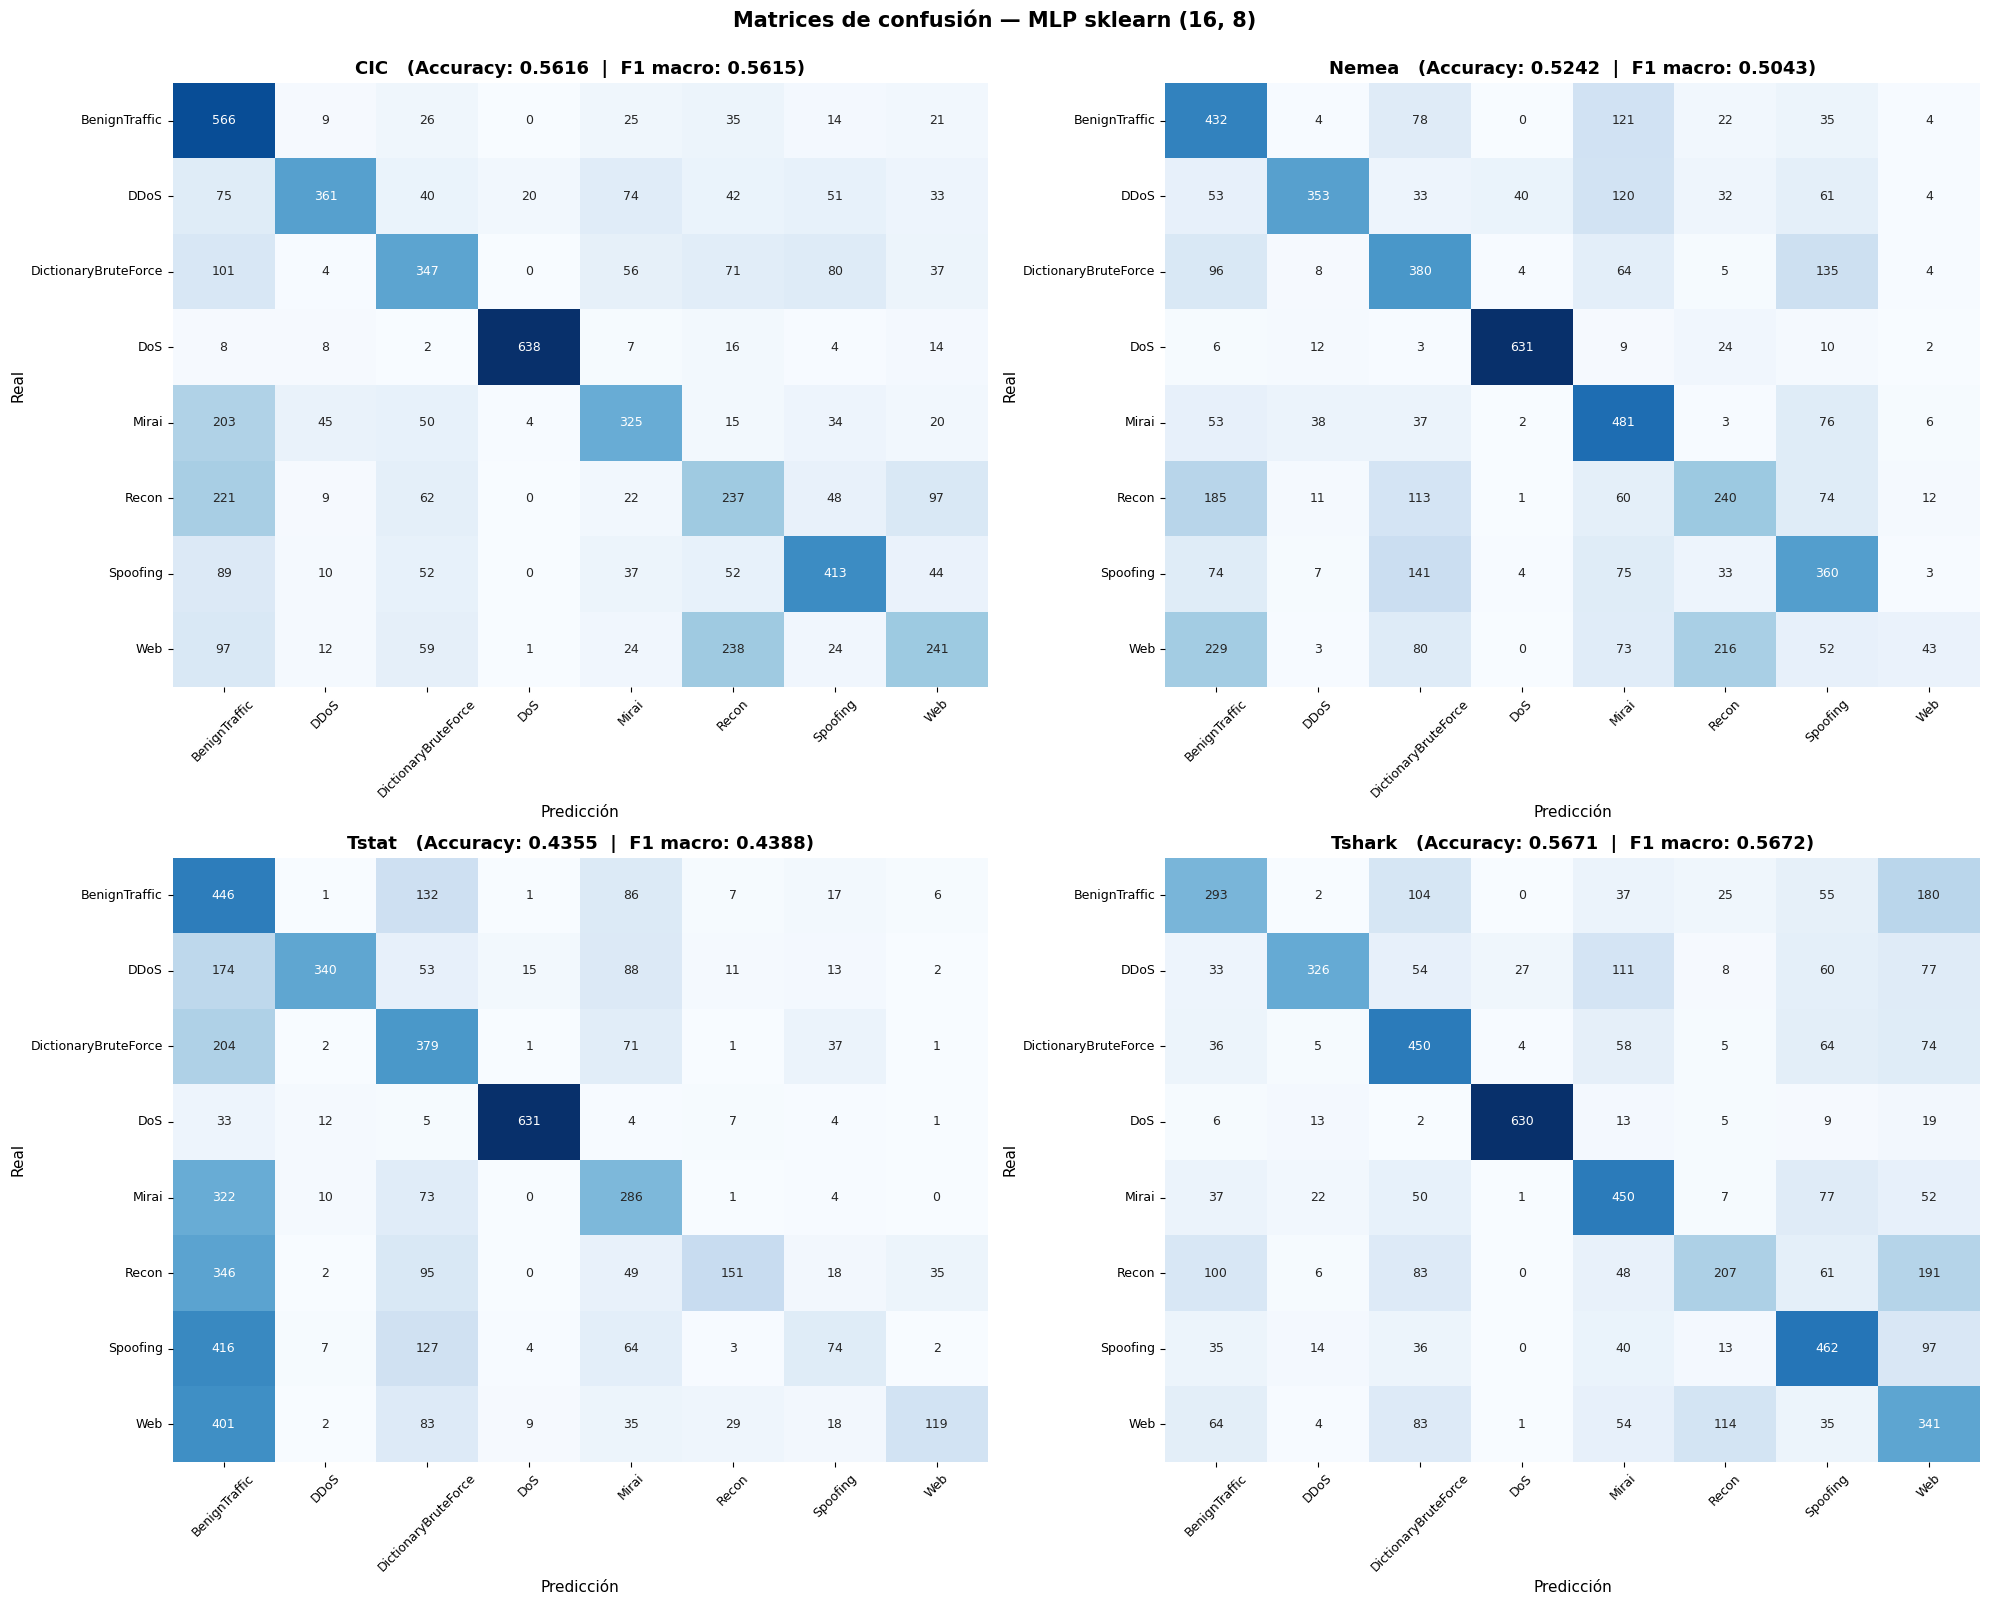

In [6]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (grid 2×2)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, herr in enumerate(HERRAMIENTAS):
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    ax = axes[i]

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nombres, yticklabels=nombres,
        ax=ax, cbar=False, square=False,
        annot_kws={'size': 9}
    )

    acc = next(r['Accuracy'] for r in resultados if r['Herramienta'] == herr)
    f1  = next(r['F1 macro'] for r in resultados if r['Herramienta'] == herr)
    ax.set_title(f'{herr}   (Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Matrices de confusión — MLP sklearn (16, 8)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

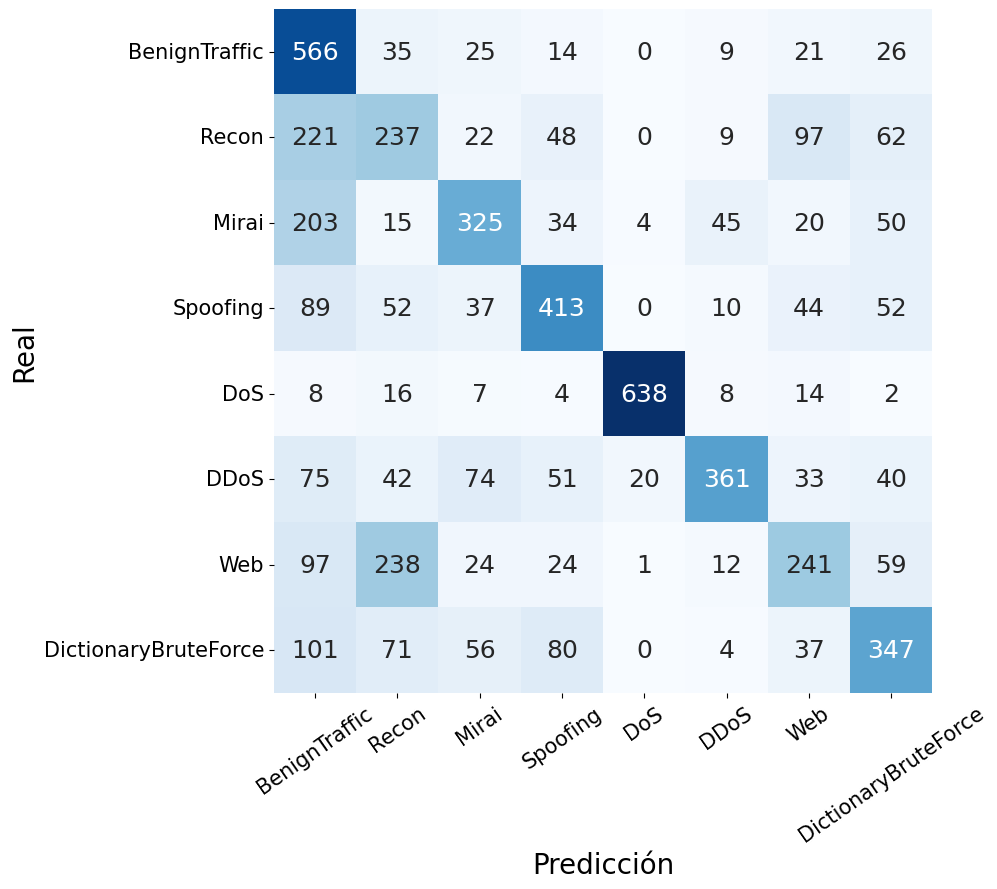

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpsk_basico_CIC.pdf


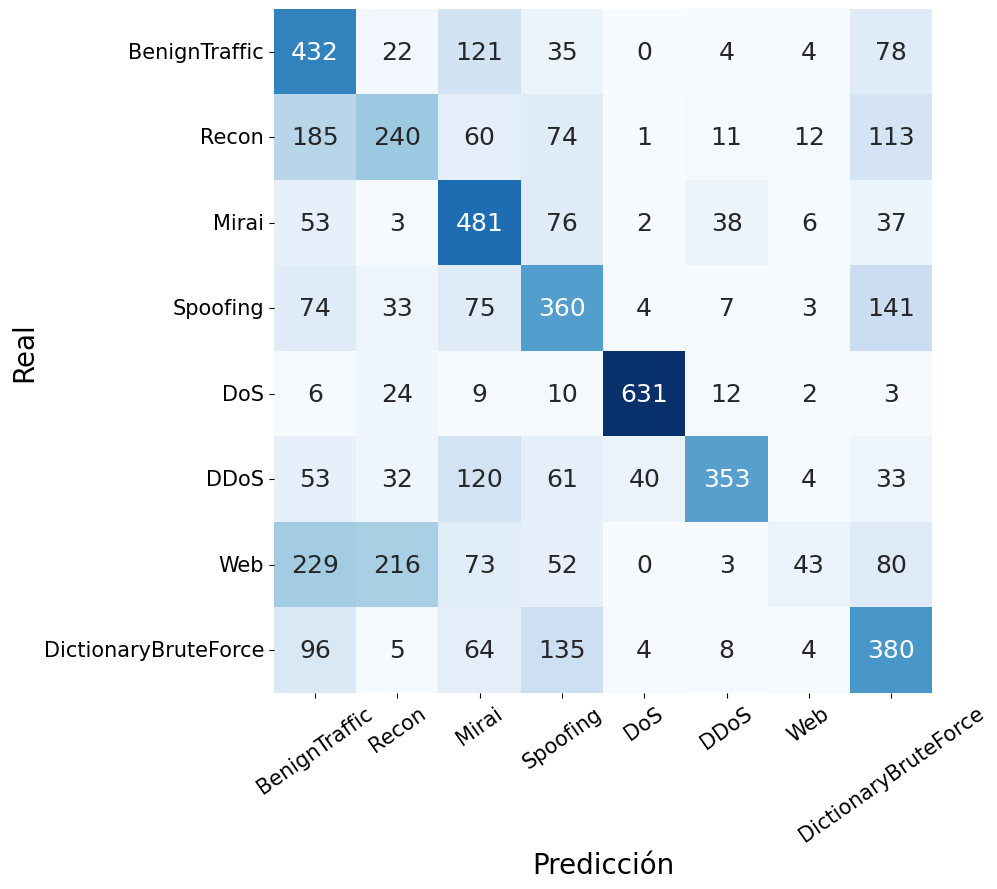

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpsk_basico_Nemea.pdf


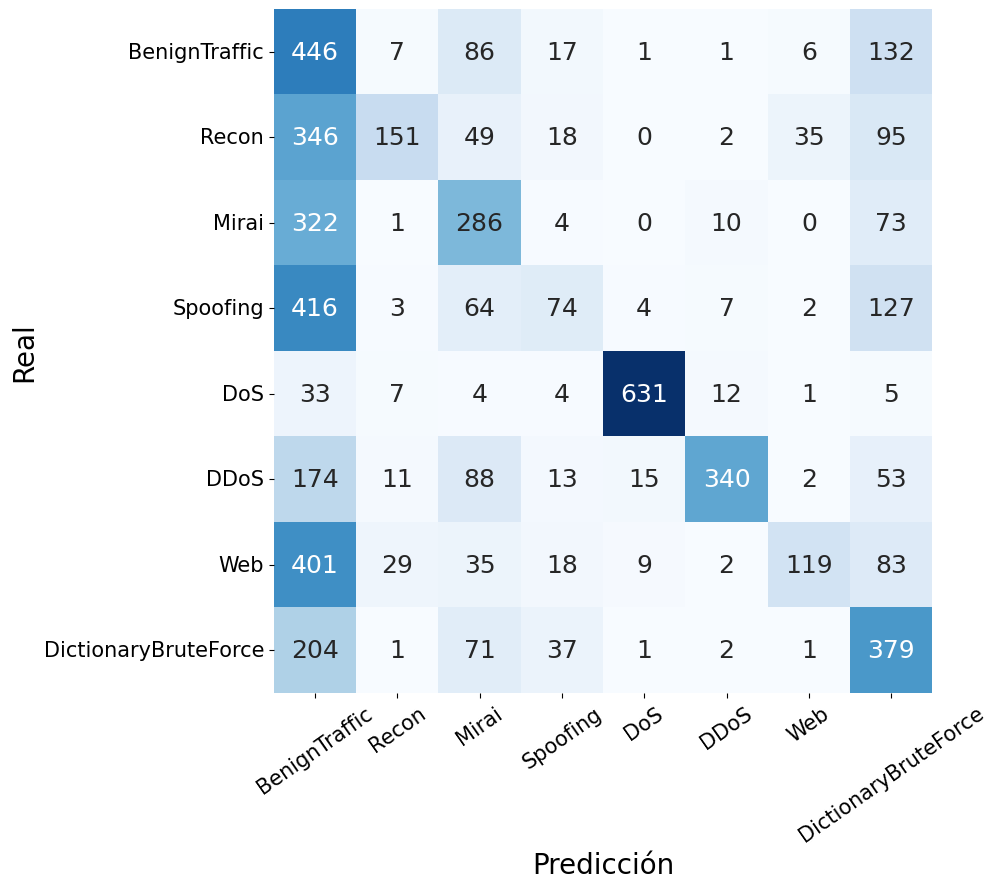

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpsk_basico_Tstat.pdf


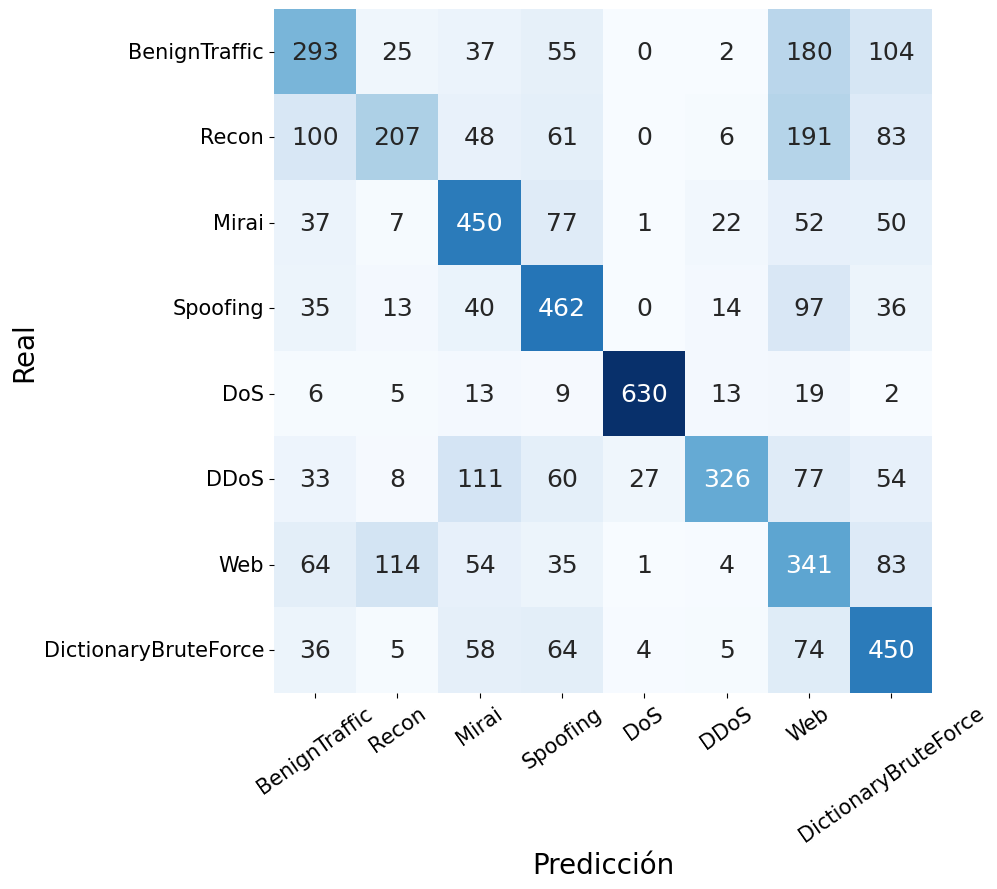

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_mlpsk_basico_Tshark.pdf


In [7]:
# ============================================================
# CELDA 6 — Matrices de confusión (4 PDF separados, uno por herramienta)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']

for herr in HERRAMIENTAS:
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    perm = [nombres.index(c) for c in ORDEN_FIGURA]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()
    ruta_pdf = RUTA_FIGURAS / f'cm_mlpsk_basico_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

In [8]:
import numpy as np

BYTES_MEDIO_FLUJO = {
    'CIC':    48,
    'Nemea':  101,
    'Tstat':  51,
    'Tshark': 206
} 

print('\n' + '='*70)
print('  THROUGHPUT — MLP-sklearn')
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for res in resultados:
    herr = res['Herramienta']
    us_muestra = res['Pred us/muestra']
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — MLP-sklearn
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                  1.2        805401               309.3
  Nemea                1.9        531577               429.5
  Tstat                2.4        417579               170.4
  Tshark               2.2        457510               754.0
